In [1]:
#All packages needed to run TwINFER simulation and inference are listed here. 
#If any of them are not installed, please install them using pip or conda env.
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numba
import tqdm
import scipy
import seaborn
import os
import sys
import joblib
import itertools
from itertools import product
from collections import defaultdict
from itertools import combinations

/home/gzu5140/minicondacurl/envs/twinfer/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


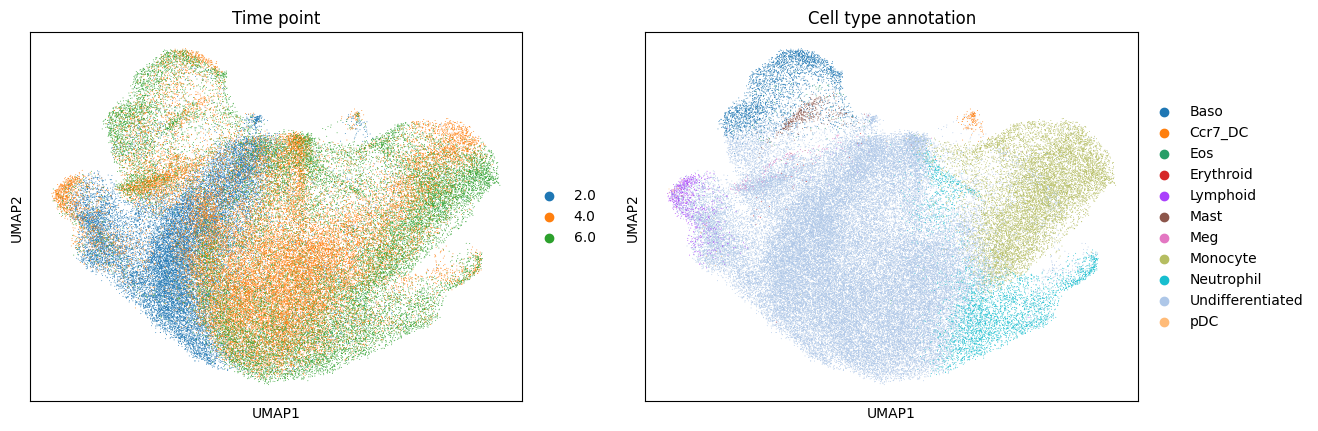

In [2]:
import scanpy as sc

# Load data
adata = sc.read_h5ad('/home/gzu5140/Keerthana_b1042/grnInference/real_data/Larry_data/LSK_d2_d4_d6.h5ad')
adata.obs_names_make_unique()

# Plot UMAP
sc.pl.umap(adata, color=['Time point', 'Cell type annotation'])

In [ ]:
# from mygene import MyGeneInfo

# # Calculate cell cycle scores
# cell_cycle_genes = [x.strip() for x in open('/home/gzu5140/Keerthana_b1042/grnInference/real_data/Larry_data/regev_lab_cell_cycle_genes.txt', encoding='utf-8-sig')]
# s_genes = cell_cycle_genes[:43]
# g2m_genes = cell_cycle_genes[43:]

# mg = MyGeneInfo()
# mouse_cell_cycle_genes = mg.querymany(cell_cycle_genes, scopes='symbol', fields='symbol', species='mouse')
# mouse_cell_cycle_genes = [entry['symbol'] for entry in mouse_cell_cycle_genes if 'symbol' in entry]
# mouse_s_genes = mg.querymany(s_genes, scopes='symbol', fields='symbol', species='mouse')
# mouse_s_genes = [entry['symbol'] for entry in mouse_s_genes if 'symbol' in entry]
# mouse_g2m_genes = mg.querymany(g2m_genes, scopes='symbol', fields='symbol', species='mouse')
# mouse_g2m_genes = [entry['symbol'] for entry in mouse_g2m_genes if 'symbol' in entry]

# mouse_cell_cycle_genes = [x for x in mouse_cell_cycle_genes if x in adata.var_names]
# mouse_s_genes = [x for x in mouse_s_genes if x in adata.var_names]
# mouse_g2m_genes = [x for x in mouse_g2m_genes if x in adata.var_names]
# sc.tl.score_genes_cell_cycle(adata, s_genes=mouse_s_genes, g2m_genes=mouse_g2m_genes)

In [3]:
from scipy.stats import mannwhitneyu

def compute_distances(adata):
    # assuming that the data is sorted by pair IDs
    pca = adata.obsm['X_pca']
    distances = pca[::2,:] - pca[1::2,:]
    distances = np.linalg.norm(distances, axis=1)
    return distances

def get_significance_symbol(pval):
    if pval > 0.05:
        return 'ns'
    elif pval <= 0.0001:
        return '****'
    elif pval <= 0.001:
        return '***'
    elif pval <= 0.01:
        return '**'
    else:
        return '*'

def add_stat_annotation(ax, category_a, category_b, label, subset, x0, level=0):
    """Draws a bracket and annotation between two y-categories."""
    # Get category positions (bottom to top)
    yticklabels = list(subset['pair_type'].drop_duplicates())  # categories actually present in the data, in order
    y1 = yticklabels.index(category_a)
    y2 = yticklabels.index(category_b)
    y_min, y_max = min(y1, y2), max(y1, y2)
    y_mid = (y1 + y2) / 2

    # Base offset
    x_offset = 0.5 + level * np.ceil(x0)/4  # spacing between bracket levels
    x = x0 + x_offset

    # Draw bracket
    ax.plot([x, x + 1, x + 1, x],
            [y_min, y_min, y_max, y_max],
            lw=1.5, color='black', clip_on=False)
    
    # Label at midpoint
    ax.text(x + 1.3, y_mid, label, va='center', ha='left', fontsize=12)

In [78]:
#Identify if gene list is present in the dataset

gene_list_1 = ['Muc13', 'Srgn', 'Ccl9', 'Elane', 'Igfbp4', 'Rbms1', 'Sirpa', 'Set', 'Tk1', 'Spp1']
gene_list_2 = ['Pou5f1', 'Sox2', 'Nanog', 'Klf4', 'Myc', 'Zfp42', 'Zfp281']
gene_list_3 = ['Sp1', 'Nfya', 'E2f1', 'Myc', 'Max', 'Nrf1', 'Tbp', 'Taf1', 'Atf4', 'Creb1', 'Usf1', 'Sp3', 'Klf4', 'Cebpb', 'Yy1']
#replaced mll4 with gps2 and Gltscr1 not found
gene_list = ['Brd9', 'Wdr82', 'Smarcd2', 'Smarcd1', 'Bcl11a', 'Stag2', 'Setd1b', 'Gps2', 'Men1', 'Chd4', 'Kmt2a', 'Smc2', 'Phf10', 'Cbx3', 'Crebbp', 'Hdac3', 'Setdb2', 'Ehmt2', 'Mbd2', 'Setdb1', 'Rbbp4', 'Hdac1', 'Mbd3', 'Rcor1', 'Atf7ip', 'Hmgxb4', 'Carm1', 'Prmt5', 'Cebpa', 'Ash1l', 'Smarcb1', 'Ezh2', 'Chaf1a', 'Prmt1', 'Ehmt1', 'Smc4', 'Smc3', 'Chmp2a', 'Kdm6a', 'Spi1', 'Gata2']

all_genes = {g.lower() for g in adata.var_names}
gene_list_check =  [g.lower() for g in gene_list]
found = [a for a in gene_list_check if a in all_genes]
print(f"Found {len(found)} genes out of {len(gene_list_check)}")
if found:
    print("✅ Found gene(s):", found)
else:
    print("❌ Not found in dataset")

Found 41 genes out of 41
✅ Found gene(s): ['brd9', 'wdr82', 'smarcd2', 'smarcd1', 'bcl11a', 'stag2', 'setd1b', 'gps2', 'men1', 'chd4', 'kmt2a', 'smc2', 'phf10', 'cbx3', 'crebbp', 'hdac3', 'setdb2', 'ehmt2', 'mbd2', 'setdb1', 'rbbp4', 'hdac1', 'mbd3', 'rcor1', 'atf7ip', 'hmgxb4', 'carm1', 'prmt5', 'cebpa', 'ash1l', 'smarcb1', 'ezh2', 'chaf1a', 'prmt1', 'ehmt1', 'smc4', 'smc3', 'chmp2a', 'kdm6a', 'spi1', 'gata2']


In [3]:
t1 = 2
t2 = 4

In [9]:
# ########## NEW ##########

# ### Create input file
# # Separate by time point
# adata_t1 = adata[(adata.obs['Time point'] == t1) & (adata.obs['clone_id'] != -1)].copy()
# adata_t2 = adata[(adata.obs['Time point'] == t2) & (adata.obs['clone_id'] != -1)].copy()

# # Pick subset of genes
# gene_subset = [s + '_mRNA' for s in gene_list]

# # Save cell IDs in .obs
# adata_t1.obs['cell_id'] = adata_t1.obs_names
# adata_t2.obs['cell_id'] = adata_t2.obs_names


# ### Create tables for t1 and t2 twin pairs
# for adata_t, timepoint in zip([adata_t1,adata_t2], ['t1','t2']):
#     rows = []   
#     for clone_id, group in adata_t.obs.groupby('clone_id'):
#         cells = group['cell_id'].tolist()
#         pair_counter = 0 
#         for c1, c2 in itertools.combinations(cells, 2):
#             pair_id = f"{clone_id}_p{pair_counter}_{timepoint}"
#             rows.append({
#                 'clone_id': clone_id,
#                 'pair_id': pair_id,
#                 'cell_id': c1,
#                 'replicate': 1
#             })
#             rows.append({
#                 'clone_id': clone_id,
#                 'pair_id': pair_id,
#                 'cell_id': c2,
#                 'replicate': 2
#             })
#             pair_counter += 1
    
#     if timepoint == 't1':
#         t1_data = pd.DataFrame(rows)
#     else:
#         t2_data = pd.DataFrame(rows)

# t1_data['time_step'] = np.repeat(t1, len(t1_data))
# t2_data['time_step'] = np.repeat(t2, len(t2_data))

# t1_data[gene_subset] = adata_t1[t1_data.cell_id, gene_list].X.toarray()
# t2_data[gene_subset] = adata_t2[t2_data.cell_id, gene_list].X.toarray()


# ### Create tables for across t twin pairs
# across_t_clones = list(set(adata_t1.obs.clone_id).intersection(adata_t2.obs.clone_id))
# adata_t1_sub = adata_t1[adata_t1.obs.clone_id.isin(across_t_clones)]
# adata_t2_sub = adata_t2[adata_t2.obs.clone_id.isin(across_t_clones)]

# rows_t1 = []
# rows_t2 = []
# for clone_id in across_t_clones:
#     cells_t1 = adata_t1_sub[adata_t1_sub.obs.clone_id == clone_id].obs['cell_id'].tolist()
#     cells_t2 = adata_t2_sub[adata_t2_sub.obs.clone_id == clone_id].obs['cell_id'].tolist()
#     pair_counter = 0 
#     for cell_t1 in cells_t1:
#         for cell_t2 in cells_t2:
#             pair_id = f"{clone_id}_p{pair_counter}_across_t"
#             rows_t1.append({
#                 'clone_id': clone_id,
#                 'pair_id': pair_id,
#                 'cell_id': cell_t1,
#                 'replicate': 1,
#                 'time_step': t1
#             })
#             rows_t2.append({
#                 'clone_id': clone_id,
#                 'pair_id': pair_id,
#                 'cell_id': cell_t2,
#                 'replicate': 2,
#                 'time_step': t2
#             })
#             pair_counter += 1

# across_t_data_t1 = pd.DataFrame(rows_t1)
# across_t_data_t2 = pd.DataFrame(rows_t2)

# across_t_data_t1[gene_subset] = adata_t1[across_t_data_t1.cell_id, gene_list].X.toarray()
# across_t_data_t2[gene_subset] = adata_t2[across_t_data_t2.cell_id, gene_list].X.toarray()
# across_t_data = pd.concat([across_t_data_t1, across_t_data_t2])


# ### Print number of twin pairs
# print(f"Number of t1 twins: {int(t1_data.shape[0]/2)}")
# print(f"Number of t2 twins: {int(t2_data.shape[0]/2)}")
# print(f"Number of across t twins: {int(across_t_data_t1.shape[0])}")

# del rows, rows_t1, rows_t2

Number of t1 twins: 1610
Number of t2 twins: 7573
Number of across t twins: 3005


In [ ]:
# Compute distances in PC space
distances_t1 = compute_distances(adata_t1[t1_data.cell_id])
distances_t2 = compute_distances(adata_t2[t2_data.cell_id])
distances_across_t = adata_t1[across_t_data_t1.cell_id].obsm['X_pca'] - adata_t2[across_t_data_t2.cell_id].obsm['X_pca']
distances_across_t = np.linalg.norm(distances_across_t, axis=1)

# Cell cycle synchronization
in_sync_t1 = adata_t1[t1_data.cell_id].obs['phase'][::2].values == adata_t1[t1_data.cell_id].obs['phase'][1::2].values
in_sync_t2 = adata_t2[t2_data.cell_id].obs['phase'][::2].values == adata_t2[t2_data.cell_id].obs['phase'][1::2].values

# Random
np.random.seed(42)
t1_cell_ids = adata_t1.obs['cell_id'].values.tolist()
randomly_drawn_cell_ids = np.random.choice(t1_cell_ids, size=t1_data.shape[0], replace=True)
distances_random_t1 = adata_t1[randomly_drawn_cell_ids[::2]].obsm['X_pca'] - adata_t1[randomly_drawn_cell_ids[1::2]].obsm['X_pca']
distances_random_t1 = np.linalg.norm(distances_random_t1, axis=1)
in_sync_random_t1 = adata_t1[randomly_drawn_cell_ids[::2]].obs['phase'].values == adata_t1[randomly_drawn_cell_ids[1::2]].obs['phase'].values

t2_cell_ids = adata_t2.obs['cell_id'].values.tolist()
randomly_drawn_cell_ids = np.random.choice(t2_cell_ids, size=t2_data.shape[0], replace=True)
distances_random_t2 = adata_t2[randomly_drawn_cell_ids[::2]].obsm['X_pca'] - adata_t2[randomly_drawn_cell_ids[1::2]].obsm['X_pca']
distances_random_t2 = np.linalg.norm(distances_random_t2, axis=1)
in_sync_random_t2 = adata_t2[randomly_drawn_cell_ids[::2]].obs['phase'].values == adata_t2[randomly_drawn_cell_ids[1::2]].obs['phase'].values

randomly_drawn_cell_ids_t1 = np.random.choice(t1_cell_ids, size=across_t_data_t1.shape[0], replace=True)
randomly_drawn_cell_ids_t2 = np.random.choice(t2_cell_ids, size=across_t_data_t2.shape[0], replace=True)
distances_random_across_t = adata_t1[randomly_drawn_cell_ids_t1].obsm['X_pca'] - adata_t2[randomly_drawn_cell_ids_t2].obsm['X_pca']
distances_random_across_t = np.linalg.norm(distances_random_across_t, axis=1)

# Create dataframe for plotting
df_distances = pd.DataFrame({
    'Transcriptomic distance [a.u.]': np.concatenate([distances_t1, distances_t2, distances_across_t,
                                distances_random_t1, distances_random_t2, distances_random_across_t]),
    'pair_type': (['Clonal pairs'] * len(distances_t1) +
                  ['Clonal pairs'] * len(distances_t2) +
                  ['Clonal pairs'] * len(distances_across_t) +
                  ['Random pairs'] * len(distances_random_t1) +
                  ['Random pairs'] * len(distances_random_t2) +
                  ['Random pairs'] * len(distances_random_across_t)),
    'in_sync': np.concatenate([in_sync_t1, in_sync_t2, np.array([np.nan]*len(distances_across_t)),
                               in_sync_random_t1, in_sync_random_t2, np.array([np.nan]*len(distances_random_across_t))]),
    'timepoint': (['T1'] * len(distances_t1) +
                  ['T2'] * len(distances_t2) +
                  ['Across T'] * len(distances_across_t) +
                  ['T1'] * len(distances_random_t1) +
                  ['T2'] * len(distances_random_t2) +
                  ['Across T'] * len(distances_random_across_t))
})

In [ ]:
# Create three subplots one comparing T1 clonal to random pairs, T2 clonal to random, and across T clonal to random
fig, axes = plt.subplots(1, 3, figsize=(15, 2), sharey=True)
for ax, timepoint in zip(axes, ['T1', 'T2', 'Across T']):
    subset = df_distances[df_distances['timepoint'] == timepoint]
    sns.boxplot(data=subset, 
                x='Transcriptomic distance [a.u.]', y='pair_type', hue='pair_type',
                palette={'Clonal pairs': 'lightgray', 'Random pairs': 'gray'},
                ax=ax)
    sns.despine(right=True, top=True, ax=ax)
    ax.set_ylabel('')
    ax.set_title(timepoint)
    
    # Statistical annotation
    clonal_distances = subset[subset['pair_type'] == 'Clonal pairs']['Transcriptomic distance [a.u.]']
    random_distances = subset[subset['pair_type'] == 'Random pairs']['Transcriptomic distance [a.u.]']
    stat, pval = mannwhitneyu(clonal_distances, random_distances, alternative='two-sided')
    significance_label = get_significance_symbol(pval)
    add_stat_annotation(ax, 'Clonal pairs', 'Random pairs', significance_label, subset, 
                        x0=max(subset['Transcriptomic distance [a.u.]'] + 0.05*max(subset['Transcriptomic distance [a.u.]'])))
plt.tight_layout()

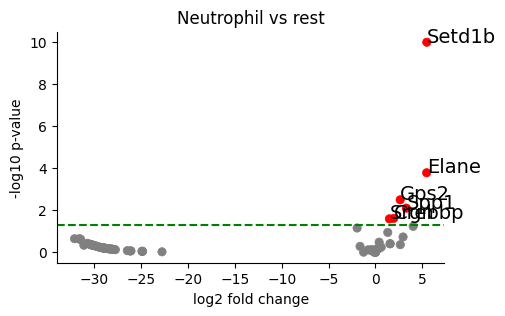

In [81]:
# Create volcano plot from adata_t1 for gene expression for monocyte vs rest
from scipy.stats import mannwhitneyu

# Create volcano plot from adata_t1 for gene expression for monocyte vs rest
def volcano_plot(adata, groupby, group, genes, pval_threshold=0.05):
    # Subset data
    adata_group1 = adata[adata.obs[groupby] == group]
    adata_group2 = adata[adata.obs[groupby] != group]
    mean_g1_list = []
    mean_g2_list = []
    # Initialize lists to store results
    logfc_list = []
    pval_list = []
    
    # Iterate over genes
    for gene in genes:
        expr_group1 = np.expm1(adata_group1[:, gene].X.toarray()).flatten()
        expr_group2 = np.expm1(adata_group2[:, gene].X.toarray()).flatten()
        
        # Calculate log fold change
        mean_group1 = np.mean(expr_group1)
        mean_group2 = np.mean(expr_group2)
        logfc = np.log2((mean_group1 + 1e-9) / (mean_group2 + 1e-9))  # add small constant to avoid division by zero
        logfc_list.append(logfc)
        
        # Perform Mann-Whitney U test
        stat, pval = mannwhitneyu(expr_group1, expr_group2, alternative='two-sided')
        pval_list.append(pval)
        mean_g1_list.append(mean_group1)
        mean_g2_list.append(mean_group2)
    # Create DataFrame for plotting
    df_results = pd.DataFrame({
        'gene': genes,
        'mean_g1': mean_g1_list,
        'mean_g2': mean_g2_list,
        'logFC': logfc_list,
        'pval': pval_list
    })
    df_results['neg_log10_pval'] = -np.log10(df_results['pval'] + 1e-10)  # add small constant to avoid log(0)
    
    # Determine significance
    df_results['significant'] = df_results['pval'] <= pval_threshold
    
    # Plot volcano plot
    plt.figure(figsize=(5, 3))
    sns.scatterplot(data=df_results, x='logFC', y='neg_log10_pval', hue='significant', palette={True: 'red', False: 'gray'}, edgecolor=None)
    # Add text labels for significant genes
    for _, row in df_results.iterrows():
        if row['significant']:
            plt.text(row['logFC'], row['neg_log10_pval'], row['gene'], fontsize=14)
    # Add threshold line
    plt.axhline(y=-np.log10(pval_threshold), color='green', linestyle='--')
    sns.despine(right=True, top=True)
    plt.title(f'{group} vs rest')
    plt.xlabel('log2 fold change')
    plt.ylabel('-log10 p-value')
    # plt.legend(title='Significant')
    # No legend
    plt.legend([],[], frameon=False)
    plt.show()
    return df_results

# To be replaced with gene list of interest
# genes = ['Brd9', 'Wdr82', 'Smarcd2', 'Smarcd1', 'Bcl11a', 'Stag2', 'Setd1b', 'Men1', 'Chd4', 'Kmt2a', 'Smc2', 'Phf10', 'Cbx3', 'Crebbp', 'Hdac3', 'Setdb2', 'Ehmt2', 'Mbd2', 'Setdb1', 'Rbbp4', 'Hdac1', 'Mbd3', 'Rcor1', 'Atf7ip', 'Hmgxb4', 'Carm1', 'Prmt5', 'Cebpa', 'Ash1l', 'Smarcb1', 'Ezh2', 'Chaf1a', 'Prmt1', 'Ehmt1', 'Smc4', 'Smc3', 'Chmp2a', 'Kdm6a', 'Spi1', 'Gata2'] 
genes = gene_list_1 + gene_list + gene_list_2 + gene_list_3
df_results = volcano_plot(adata_t1, groupby='Cell type annotation', group='Neutrophil', genes=genes, pval_threshold=0.05)

In [75]:
pd.set_option("display.float_format", "{:.6e}".format)
df_results[abs(df_results['logFC']) > 20]


,gene,mean_g1,mean_g2,logFC,pval,neg_log10_pval,significant
0,Muc13,0.000000e+00,4.630050e+00,-3.210838e+01,2.282793e-01,6.415334e-01,False
10,Brd9,0.000000e+00,2.264827e-01,-2.775483e+01,7.553994e-01,1.218234e-01,False
11,Wdr82,0.000000e+00,1.397719e+00,-3.038043e+01,4.298574e-01,3.666756e-01,False
12,Smarcd2,0.000000e+00,1.239342e+00,-3.020693e+01,4.557049e-01,3.413163e-01,False
13,Smarcd1,0.000000e+00,4.974952e-01,-2.889011e+01,6.505356e-01,1.867289e-01,False
15,Stag2,0.000000e+00,9.306189e-02,-2.647169e+01,8.415422e-01,7.492410e-02,False
19,Chd4,0.000000e+00,3.255955e+00,-3.160043e+01,2.274449e-01,6.431238e-01,False
20,Kmt2a,0.000000e+00,7.172335e-03,-2.277401e+01,9.571292e-01,1.902943e-02,False
21,Smc2,0.000000e+00,1.813530e+00,-3.075615e+01,3.765685e-01,4.241560e-01,False
23,Cbx3,0.000000e+00,2.956701e+00,-3.146134e+01,2.384443e-01,6.226130e-01,False


In [59]:
########## OLD ##########

### Create input file
adata_t1 = adata[(adata.obs['Time point'] == t1) & (adata.obs['clone_id'] != -1)]
adata_t2 = adata[(adata.obs['Time point'] == t2) & (adata.obs['clone_id'] != -1)]

# Pick subset of genes
# gene_list = ['Muc13', 'Srgn', 'Ccl9', 'Elane', 'Igfbp4', 'Rbms1', 'Sirpa', 'Set', 'Tk1', 'Spp1']
# gene_list = ['Pou5f1', 'Sox2', 'Nanog', 'Klf4', 'Myc', 'Zfp42', 'Zfp281']
gene_list = ['Brd9', 'Gata1', 'Wdr82', 'Smarcd2', 'Smarcd1', 'Bcl11a', 'Stag2', 'Setd1b', 'Gps2', 'Men1', 'Chd4', 'Kmt2a', 'Smc2', 'Phf10', 'Cbx3', 'Crebbp', 'Hdac3', 'Setdb2', 'Ehmt2', 'Mbd2', 'Setdb1', 'Rbbp4', 'Hdac1', 'Mbd3', 'Rcor1', 'Atf7ip', 'Hmgxb4', 'Carm1', 'Prmt5', 'Cebpa', 'Ash1l', 'Smarcb1', 'Ezh2', 'Chaf1a', 'Prmt1', 'Ehmt1', 'Smc4', 'Smc3', 'Chmp2a', 'Kdm6a', 'Spi1', 'Gata2']
gene_subset = [s + '_mRNA' for s in gene_list]

# Find across t clones
across_t_clones = np.array(list(set(adata_t1.obs.clone_id.value_counts().index[adata_t1.obs.clone_id.value_counts() == 1]).intersection(adata_t2.obs.clone_id.unique())))

# From each clone, randomly pick a differentiated cell
t1_across_t_clones_cells = {}
t2_across_t_clones_cells = {}
adata_t2_across = adata_t2[adata_t2.obs.clone_id.isin(across_t_clones)]
for clone in across_t_clones:
    t1_across_t_clones_cells[clone] = adata_t1[adata_t1.obs.clone_id == clone].obs_names[0]
    idx = adata_t2_across[adata_t2_across.obs.clone_id == clone].obs_names
    t2_across_t_clones_cells[clone] = np.random.choice(idx, size=1)[0]

# create csv file
across_t_data_t1 = pd.DataFrame(columns=['clone_id', 'cell_id', 'time_step', 'replicate'] + gene_subset)
across_t_data_t1['cell_id'] = list(t1_across_t_clones_cells.values())
across_t_data_t1['clone_id'] = list(t1_across_t_clones_cells.keys())
across_t_data_t1['time_step'] = np.repeat(t1, len(across_t_data_t1))
across_t_data_t1['replicate'] = np.repeat(1, len(across_t_data_t1))
across_t_data_t1[gene_subset] = adata_t1[across_t_data_t1['cell_id'], gene_list].X.toarray()

across_t_data_t2 = pd.DataFrame(columns=['clone_id', 'cell_id', 'time_step', 'replicate'] + gene_subset)
across_t_data_t2['cell_id'] = list(t2_across_t_clones_cells.values())
across_t_data_t2['clone_id'] = list(t2_across_t_clones_cells.keys())
across_t_data_t2['time_step'] = np.repeat(t2, len(across_t_data_t2))
across_t_data_t2['replicate'] = np.repeat(2, len(across_t_data_t2))
across_t_data_t2[gene_subset] = adata_t2[across_t_data_t2['cell_id'], gene_list].X.toarray()

across_t_data = pd.concat([across_t_data_t1, across_t_data_t2])
# across_t_data.to_csv('LARRY_across_t_twins.csv')

# Excluding across t clones, pick all two-cell clones from t1
temp = adata_t1[~adata_t1.obs.clone_id.isin(across_t_clones)].obs.clone_id.value_counts()
t1_clones = np.array(list(temp.index[temp == 2]))

# create csv file
t1_data = pd.DataFrame(columns=['clone_id', 'cell_id', 'time_step', 'replicate'] + gene_subset)
t1_data['cell_id'] = adata_t1[adata_t1.obs.clone_id.isin(t1_clones)].obs_names
t1_data['clone_id'] = adata_t1[adata_t1.obs.clone_id.isin(t1_clones)].obs['clone_id'].values
t1_data['time_step'] = np.repeat(t1, len(t1_data))
t1_data['replicate'] = t1_data.groupby("clone_id").cumcount() + 1
t1_data[gene_subset] = adata_t1[t1_data['cell_id'], gene_list].X.toarray()
# t1_data.to_csv('LARRY_t1_twins.csv')

# Excluding across t clones, find clones with 2 cells
temp = adata_t2[(~adata_t2.obs.clone_id.isin(across_t_clones)) & (~adata_t2.obs.clone_id.isin(t1_clones))].obs.clone_id.value_counts()
# t2_clones = np.array(list(temp.index[temp == 2]))
t2_clones = np.array(list(temp.index[temp != 1]))

# From each of these clones, randomly pick two cells
adata_t2_within = adata_t2[adata_t2.obs.clone_id.isin(t2_clones)]
t2_within_clones_cells = {}
for clone in t2_clones:
    idx = adata_t2_within[adata_t2_within.obs.clone_id == clone].obs_names
    t2_within_clones_cells[clone] = list(np.random.choice(idx, size=2))

t2_data = pd.DataFrame(columns=['clone_id', 'cell_id', 'time_step', 'replicate'] + gene_subset)
# t2_data['cell_id'] = adata_t2[adata_t2.obs.clone_id.isin(t2_clones)].obs_names
# t2_data['clone_id'] = adata_t2[adata_t2.obs.clone_id.isin(t2_clones)].obs['clone_id'].values
t2_data['cell_id'] = np.array(list(t2_within_clones_cells.values())).reshape(-1)
t2_data['clone_id'] = np.repeat(np.array(list(t2_within_clones_cells.keys())), 2)
t2_data['time_step'] = np.repeat(t2, len(t2_data))
t2_data['replicate'] = t2_data.groupby("clone_id").cumcount() + 1
t2_data[gene_subset] = adata_t2[t2_data['cell_id'], gene_list].X.toarray()
# t2_data.to_csv('LARRY_t2_twins.csv')

# Subsample if t1_data << t2_data
if int(t1_data.shape[0]/2)*1.5 <= int(t2_data.shape[0]/2):
    t2_clones = t2_data.clone_id.unique()
    np.random.seed(42)
    t2_clones_sub = np.random.choice(t2_clones, size=int(t1_data.shape[0]/2), replace=False)
    t2_data = t2_data[t2_data.clone_id.isin(t2_clones_sub)]

# t1_data = pd.read_csv('/Users/idabueschel/Code/twINFER/TwINFER/LARRY_t1_twins.csv', index_col=0, sep=',')
# t2_data = pd.read_csv('/Users/idabueschel/Code/twINFER/TwINFER/LARRY_t2_twins.csv', index_col=0, sep=',')
# across_t_data = pd.read_csv('/Users/idabueschel/Code/twINFER/TwINFER/LARRY_across_t_twins.csv', index_col=0, sep=',')

twin_data = pd.concat([t1_data, t2_data, across_t_data])
# twin_data.to_csv('LARRY_twins.csv')

print(f"Number of t1 twins: {int(t1_data.shape[0]/2)}")
print(f"Number of t2 twins: {int(t2_data.shape[0]/2)}")
print(f"Number of across t twins: {int(across_t_data.shape[0]/2)}")

Number of t1 twins: 621
Number of t2 twins: 621
Number of across t twins: 593


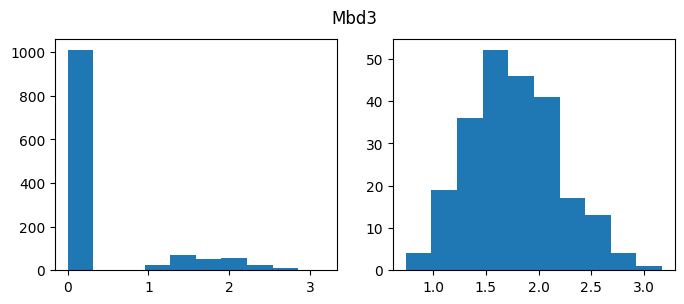

In [38]:
adata_temp = adata_t1[adata_t1.obs['clone_id'].isin(t1_data.clone_id.unique()), gene_list].copy()
for gene in ['Mbd3']:
    fig, ax = plt.subplots(1,2, figsize=(8,3))
    data = adata_temp[:, gene].X.toarray()
    ax[0].hist(data)
    ax[1].hist(data[data != 0])
    plt.suptitle(gene)
    plt.show()

# sc.pl.umap(adata_temp, color=['Cell type annotation'] + gene_list, cmap='Reds')

In [ ]:
adata_temp = adata_t2[adata_t2.obs['clone_id'].isin(t2_data.clone_id.unique()), gene_list].copy()
for gene in gene_list:
    fig, ax = plt.subplots(1,2, figsize=(8,3))
    data = adata_temp[:, gene].X.toarray()
    ax[0].hist(data)
    ax[1].hist(data[data != 0])
    plt.suptitle(gene)
    plt.show()

sc.pl.umap(adata_temp, color=['Cell type annotation'] + gene_list, cmap='Reds')

In [13]:
# Calculation functions
import importlib
from TwINFER_function_scripts import correlation_analysis_functions
from TwINFER_function_scripts import correlation_analysis_helpers

importlib.reload(correlation_analysis_functions)
importlib.reload(correlation_analysis_helpers)

from TwINFER_function_scripts.correlation_analysis_functions import (
    
    calculate_pairwise_gene_gene_correlation_matrix,
    check_system_in_steady_state,
    check_gene_gene_correlation_threshold,
    calculate_twin_random_pair_correlations,
    differentiate_single_state_reg_and_multiple_states,
    identify_reg_if_multiple_states,
    get_cross_correlations,
    identify_actual_directed_edges
)

# Helper functions
from TwINFER_function_scripts.correlation_analysis_helpers import (
    extract_param_index,
    read_input_matrix,
    get_param_data, 
    plot_matrix_as_heatmap,
    print_summary,
    plot_network
)

In [64]:
# Drop column clone_id and rename pair_id to clone_id
# t1_data.drop(columns=['clone_id'], inplace=True)
# t1_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
# t2_data.drop(columns=['clone_id'], inplace=True)
# t2_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
# across_t_data.drop(columns=['clone_id'], inplace=True)
# across_t_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

t1_clones = t1_data.clone_id.values
t2_clones = t2_data.clone_id.values
across_t_clones = across_t_data.clone_id.values

# Subset directly
t1_twins = t1_data
t2_twins = t2_data

# Across_t: pick exactly one random twin per clone_id
# One cell per clone at t1
across_t_twin1 = across_t_data[across_t_data.time_step == t1]
across_t_twin2 = across_t_data[across_t_data.time_step == t2]

# Reset index for cleanliness
t1_twins = t1_twins.reset_index(drop=True)
t2_twins = t2_twins.reset_index(drop=True)
across_t_twin1 = across_t_twin1.reset_index(drop=True)
across_t_twin2 = across_t_twin2.reset_index(drop=True)

all_t1_t2_measurements = pd.concat(
[t1_twins, t2_twins, across_t_twin1, across_t_twin2],
ignore_index=True
)

all_t1_measurements = pd.concat(
[t1_twins, across_t_twin1],
ignore_index=True
)
all_t2_measurements = pd.concat(
[t2_twins, across_t_twin2],
ignore_index=True
)

In [58]:
# Define input parameters
plot_correlation_matrices_as_heatmap = True
have_any_output = True
p_val_threshold_scrambled_gene_correlation = 0.05
show_scrambled_distribution_gene_correlation = False
z_score_threshold_two_states = 10

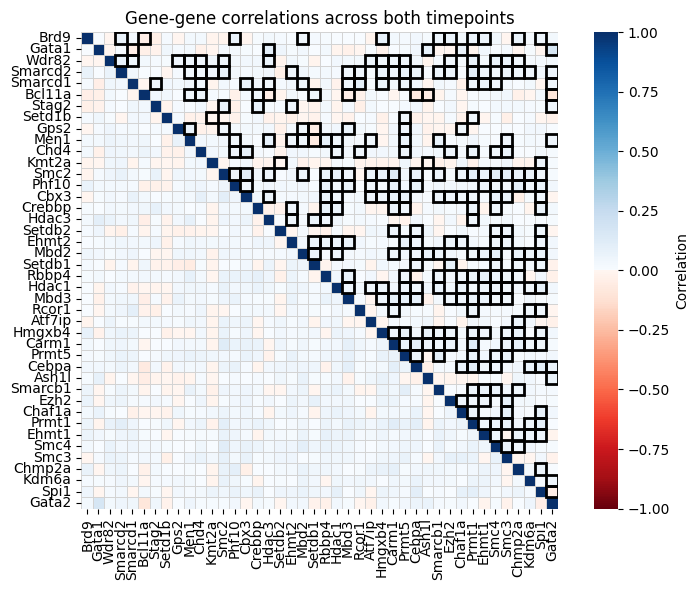

In [61]:
# --- Step 1: Pairwise gene-gene correlations at t1: day 2 ---
pairwise_gene_gene_correlation_matrix_t1 = calculate_pairwise_gene_gene_correlation_matrix(
    all_t1_measurements, gene_list
)

no_regulation_t1, potential_regulation_t1 = check_gene_gene_correlation_threshold(
    all_t1_measurements, pairwise_gene_gene_correlation_matrix_t1, gene_list,  threshold = threshold_gene_gene_corr, use_scramble = True, p_val_threshold = p_val_threshold_scrambled_gene_correlation, verbose = show_scrambled_distribution_gene_correlation, n_cores_to_use=8
)
            
# print(no_regulation)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t1, gene_list=gene_list, no_regulation=no_regulation_t1, potential_regulation=potential_regulation_t1,
        title=f"Gene-gene correlations across both timepoints", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self=True
    )

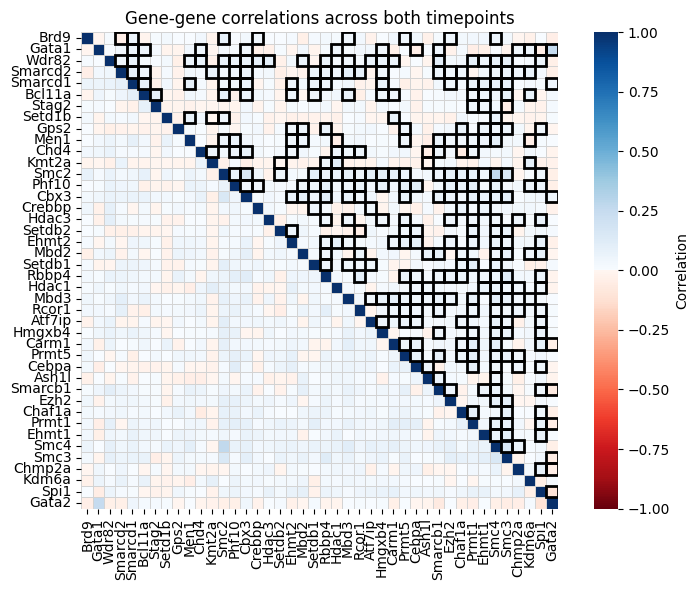

In [62]:
# --- Step 1: Pairwise gene-gene correlations at t1: day 4 ---
pairwise_gene_gene_correlation_matrix_t2 = calculate_pairwise_gene_gene_correlation_matrix(
    all_t2_measurements, gene_list
)
no_regulation_t2, potential_regulation_t2 = check_gene_gene_correlation_threshold(
    all_t2_measurements, pairwise_gene_gene_correlation_matrix_t2, gene_list,  threshold = threshold_gene_gene_corr, use_scramble = True, p_val_threshold = p_val_threshold_scrambled_gene_correlation, verbose = show_scrambled_distribution_gene_correlation,  n_cores_to_use=8
)
            
# print(no_regulation)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t2, gene_list=gene_list, no_regulation=no_regulation_t2, potential_regulation=potential_regulation_t2,
        title=f"Gene-gene correlations across both timepoints", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )

In [76]:
# --- Step 1: Pairwise gene-gene correlations at t1: day 2 ---
pairwise_gene_gene_correlation_matrix_t3 = calculate_pairwise_gene_gene_correlation_matrix(
    all_t2_measurements, gene_list
)
no_regulation_t3, potential_regulation_t3 = check_gene_gene_correlation_threshold(
    all_t2_measurements, pairwise_gene_gene_correlation_matrix_t3, gene_list,  threshold = threshold_gene_gene_corr, use_scramble = True, p_val_threshold = p_val_threshold_scrambled_gene_correlation, verbose = show_scrambled_distribution_gene_correlation
)
            
# print(no_regulation)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t3, gene_list=gene_list, no_regulation=no_regulation_t1, potential_regulation=potential_regulation_t1,
        title=f"Gene-gene correlations across both timepoints", add_gene_labels=True, add_time=False, gray_out_no_reg=False
    )

KeyboardInterrupt: 

In [28]:
import pandas as pd
from itertools import product
from pathlib import Path

out_dir = Path("/home/gzu5140/Keerthana_b1042/grnInference/analysisData/real_data_analysis/")
out_dir.mkdir(exist_ok=True)

# === Combine and save all timepoint results ===
rows = []

for tp, (no_reg, pot_reg, corr_mat) in {
    "t1": (no_regulation_t1, potential_regulation_t1, pairwise_gene_gene_correlation_matrix_t1),
    "t2": (no_regulation_t2, potential_regulation_t2, pairwise_gene_gene_correlation_matrix_t2),
    "t3": (no_regulation_t3, potential_regulation_t3, pairwise_gene_gene_correlation_matrix_t3),
}.items():

    all_pairs = set(tuple(sorted(p)) for p in no_reg + pot_reg)

    for g1, g2 in all_pairs:
        # lookup correlation (try both orders)
        if g1 in corr_mat.index and g2 in corr_mat.columns:
            corr_val = corr_mat.loc[g1, g2]
        elif g2 in corr_mat.index and g1 in corr_mat.columns:
            corr_val = corr_mat.loc[g2, g1]
        else:
            corr_val = None

        pair_sorted = tuple(sorted((g1, g2)))
        if pair_sorted in [tuple(sorted(p)) for p in pot_reg]:
            category = "potential_regulation"
        elif pair_sorted in [tuple(sorted(p)) for p in no_reg]:
            category = "no_regulation"
        else:
            category = "uncategorized"

        rows.append([g1, g2, corr_val, category, tp])

# Create DataFrame
from datetime import datetime
df = pd.DataFrame(rows, columns=["gene_1", "gene_2", "correlation", "category", "timepoint"])

# Get current date and time
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Define output filename with timestamp
outfile = out_dir / f"gene_pair_results_all_timepoints_{timestamp}.csv"

# Save file
df.to_csv(outfile, index=False)

# Print confirmation with readable date/time
print(f"✅ [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] Saved {len(df)} pairs to {outfile.name}")




✅ [2025-11-10 19:04:03] Saved 2583 pairs to gene_pair_results_all_timepoints_20251110_190403.csv


In [7]:
import pandas as pd
from pathlib import Path

# === Load saved CSV ===
out_dir = Path("/home/gzu5140/Keerthana_b1042/grnInference/analysisData/real_data_analysis/")
df = pd.read_csv(out_dir / "gene_pair_results_all_timepoints.csv")

# === Reconstruct lists and matrices ===
no_regulation = {}
potential_regulation = {}
pairwise_gene_gene_correlation_matrix = {}

for tp, sub in df.groupby("timepoint"):
    # Lists of tuples
    no_regulation[tp] = list(zip(sub.loc[sub["category"] == "no_regulation", "gene_1"],
                                 sub.loc[sub["category"] == "no_regulation", "gene_2"]))
    potential_regulation[tp] = list(zip(sub.loc[sub["category"] == "potential_regulation", "gene_1"],
                                        sub.loc[sub["category"] == "potential_regulation", "gene_2"]))
    # Pivot to matrix
    corr_mat = sub.pivot_table(index="gene_1", columns="gene_2", values="correlation")
    # make symmetric since we only stored one order per pair
    corr_mat = corr_mat.combine_first(corr_mat.T)
    pairwise_gene_gene_correlation_matrix[tp] = corr_mat
    
# === Extract t1, t2, t3 structures ===
no_regulation_t1 = no_regulation["t1"]
no_regulation_t2 = no_regulation["t2"]
no_regulation_t3 = no_regulation["t3"]

potential_regulation_t1 = potential_regulation["t1"]
potential_regulation_t2 = potential_regulation["t2"]
potential_regulation_t3 = potential_regulation["t3"]

pairwise_gene_gene_correlation_matrix_t1 = pairwise_gene_gene_correlation_matrix["t1"]
pairwise_gene_gene_correlation_matrix_t2 = pairwise_gene_gene_correlation_matrix["t2"]
pairwise_gene_gene_correlation_matrix_t3 = pairwise_gene_gene_correlation_matrix["t3"]

# Optional sanity check
for tp in ["t1", "t2", "t3"]:
    print(f"{tp}: {len(no_regulation[tp])} no-reg pairs, "
          f"{len(potential_regulation[tp])} potential-reg pairs, "
          f"matrix {pairwise_gene_gene_correlation_matrix[tp].shape}")


t1: 686 no-reg pairs, 134 potential-reg pairs, matrix (41, 41)
t2: 656 no-reg pairs, 164 potential-reg pairs, matrix (41, 41)
t3: 462 no-reg pairs, 358 potential-reg pairs, matrix (41, 41)


In [23]:
consistent_corr = list((set(potential_regulation_t1).intersection(set(potential_regulation_t2))).intersection(set(potential_regulation_t3)))
len(consistent_corr)

45

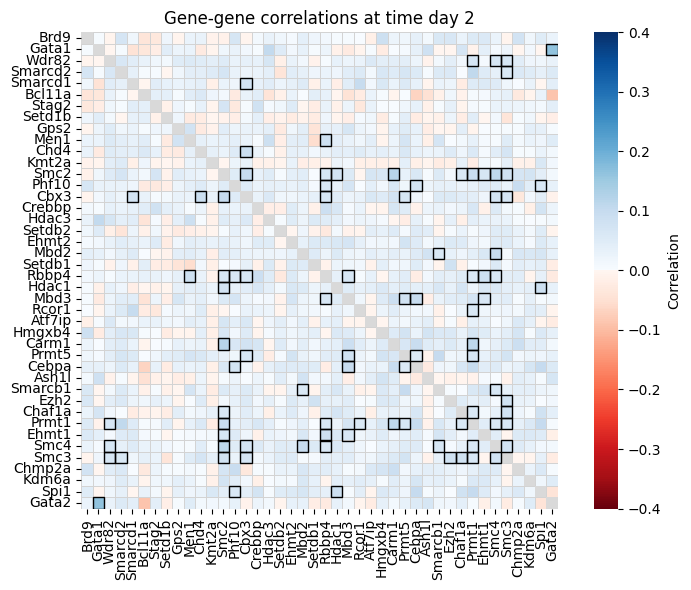

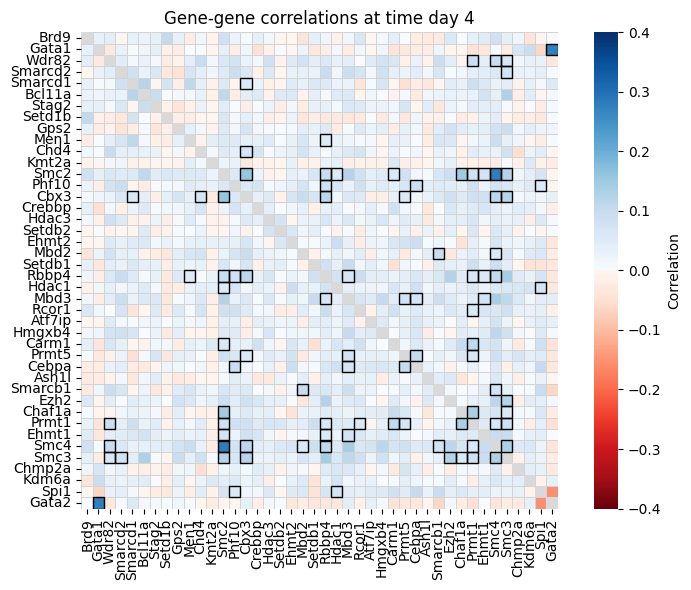

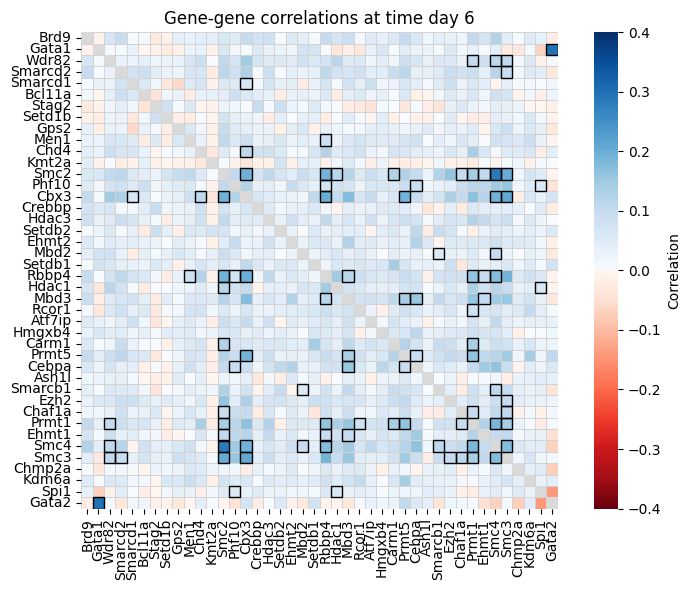

In [25]:
#Plot all 3 timepoints highlight the consistent correlations
plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t1, gene_list=gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Gene-gene correlations at time day 2", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True, vmin = -0.4, vmax = 0.4
    )
plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t2, gene_list=gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Gene-gene correlations at time day 4", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True, vmin = -0.4, vmax = 0.4
    )
plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t3, gene_list=gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Gene-gene correlations at time day 6", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True, vmin = -0.4, vmax = 0.4
    )

In [31]:
### plotting functions ###

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm, Normalize, LinearSegmentedColormap

def make_reds_blues_colormap():
    reds = plt.cm.Reds(np.linspace(1, 0, 128))   # deep red → white
    blues = plt.cm.Blues(np.linspace(0, 1, 128)) # white → deep blue
    colors = np.vstack((reds, blues))
    return LinearSegmentedColormap.from_list('RedsBlues', colors)

def plot_matrix_as_heatmap(corr_matrix, gene_list, no_regulation=None, potential_regulation=None, title=None, add_gene_labels=True,
                            add_time=False, time=None, gray_out_no_reg=False, vmin=None, vmax=None, cmap=None, 
                            return_plot=False, black_out_self=False):
    """
    Plot a gene-gene correlation matrix as a heatmap with regulatory overlays and dynamic formatting.
    """

    if add_time:
        if time is None or not isinstance(time, (list, tuple)) or len(time) == 0:
            raise ValueError("If add_time=True, you must provide a non-empty list of 1 or 2 time values in `time`.")
        if len(time) > 2:
            raise ValueError("Time can have at most two entries.")

    # Format gene names: gene_1 → g1
    base_names = [g.replace("gene_", "g") for g in gene_list]

    # Format axis labels
    if add_gene_labels:
        if add_time:
            if len(time) == 1:
                # row_labels = [f"$g{i}_{{{time[0]}}}$" for i in range(1, len(base_names) + 1)]
                # col_labels = row_labels
                row_labels = gene_list
                col_labels = gene_list
            else:
                # row_labels = [f"$g{i}_{{{time[0]}}}$" for i in range(1, len(base_names) + 1)]
                # col_labels = [f"$g{i}_{{{time[1]}}}$" for i in range(1, len(base_names) + 1)]
                row_labels = [f"${gene}_{{{time[0]}}}$" for gene in gene_list]
                col_labels = [f"${gene}_{{{time[1]}}}$" for gene in gene_list]
        else:
            row_labels = base_names
            col_labels = base_names
    else:
        row_labels = [""] * len(gene_list)
        col_labels = [""] * len(gene_list)

    # Prepare plot matrix
    plot_matrix = corr_matrix.copy()

    # --- Handle masking ---
    mask = np.zeros_like(plot_matrix.values, dtype=bool)
    if gray_out_no_reg and no_regulation:
        for g1, g2 in no_regulation:
            if g1 in gene_list and g2 in gene_list:
                i = gene_list.index(g1)
                j = gene_list.index(g2)
                plot_matrix.iloc[i, j] = 0
                mask[i, j] = True

    # --- Handle vmin/vmax auto-scaling ---
    data_values = plot_matrix.values.flatten()
    data_values = data_values[~np.isnan(data_values)]

    if len(data_values) == 0:
        vmin, vmax = -1.0, 1.0
    else:
        if vmin is None:
            vmin = np.min(data_values)
        if vmax is None:
            vmax = np.max(data_values)
        if vmin == vmax:
            vmin -= 1e-4
            vmax += 1e-4

    # --- Choose colormap adaptively ---
    if cmap is None and vmin < 0 and vmax > 0:
        cmap = make_reds_blues_colormap()
        center_span = max(abs(vmin), abs(vmax))
        norm = TwoSlopeNorm(vmin=-center_span, vcenter=0.0, vmax=center_span)
    else:
        norm = None
        if cmap is None:
            cmap = "Blues" if vmin >= 0 else "Reds"

    # --- Plot heatmap ---
    fig, ax = plt.subplots(figsize=(8, 6))

    # --- Black out diagonal if requested ---
    if black_out_self:
        for k in range(len(gene_list)):
            rect = Rectangle((k, k), 1, 1, facecolor='#D9D9D9', edgecolor='#D9D9D9')
            ax.add_patch(rect)
    heatmap = sns.heatmap(
        plot_matrix,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        norm=norm,
        xticklabels=col_labels,
        yticklabels=row_labels,
        square=True,
        cbar_kws={'label': 'Correlation'},
        linewidths=0.5,
        linecolor='lightgray',
        mask=mask
    )

    # --- Add regulation boxes ---
    if potential_regulation:
        for g1, g2 in potential_regulation:
            if g1 in gene_list and g2 in gene_list:
                i = gene_list.index(g1)
                j = gene_list.index(g2)
                rect = Rectangle((j, i), 1, 1, fill=False, edgecolor='black', linewidth=2)
                ax.add_patch(rect)

    # --- Title ---
    if title:
        if add_time:
            if len(time) == 1:
                title += f" @ time d{time[0]}"
            elif len(time) == 2:
                title += f" (rows: d{time[0]}, cols: d{time[1]})"
        ax.set_title(title, fontsize=12)

    plt.tight_layout()
    if return_plot:
        return fig, ax
    else:
        plt.show()


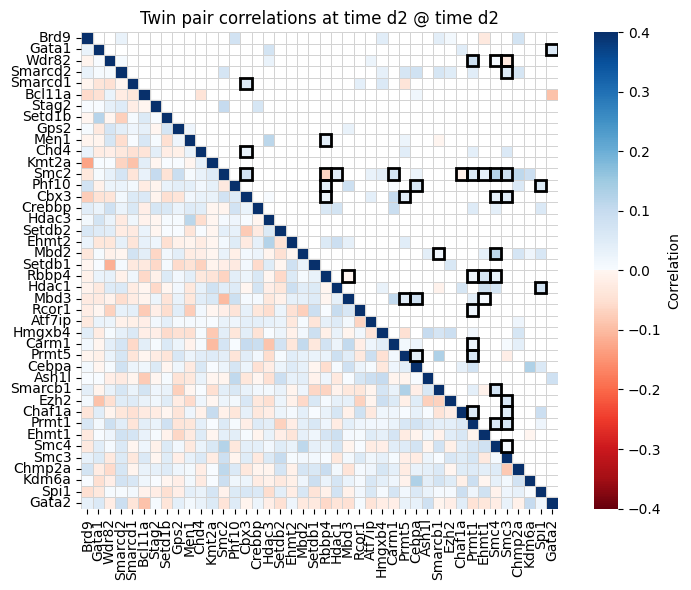

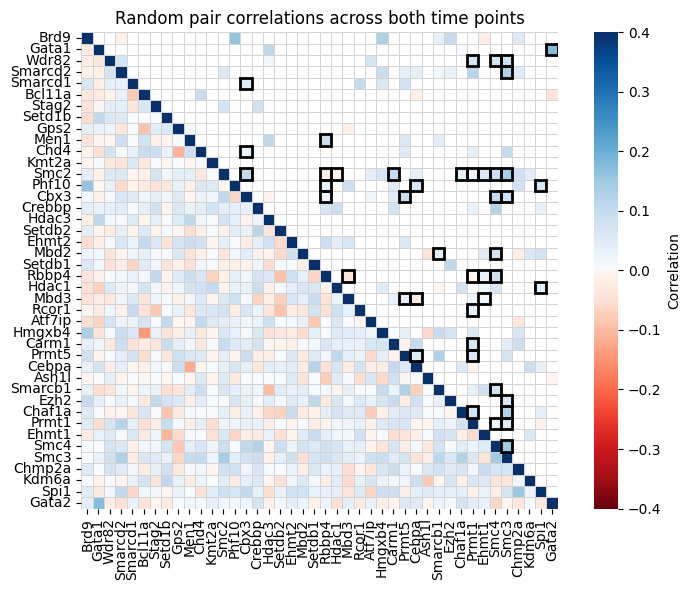

KeyboardInterrupt: 

In [32]:
# --- Step 2: Twin/random correlations at t2 ---
twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1 = calculate_twin_random_pair_correlations(
    all_t1_measurements, t1_twins, gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t1, gene_list=gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t1}", add_gene_labels=True, add_time=True, time=[t1], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )
    
    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t1, gene_list=gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t1], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t1, single_state_regulation_t1 = differentiate_single_state_reg_and_multiple_states(
    all_t1_measurements, consistent_corr, twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1, gene_list, z_score_threshold=z_score_threshold_two_states
)


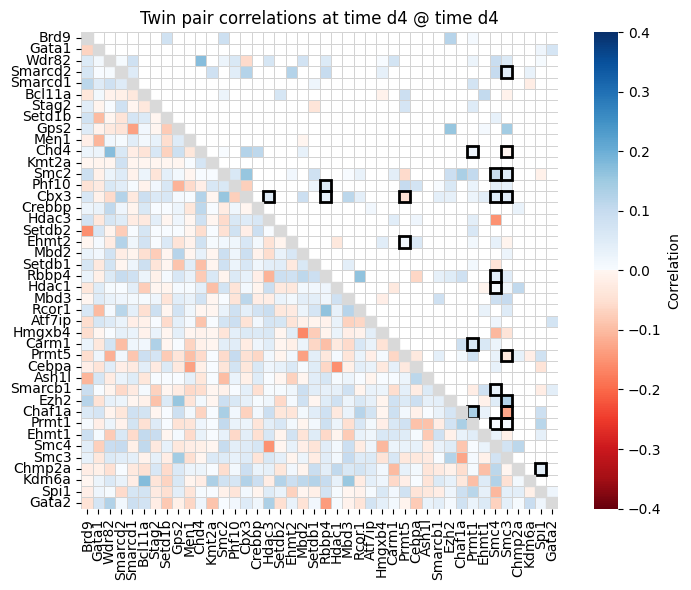

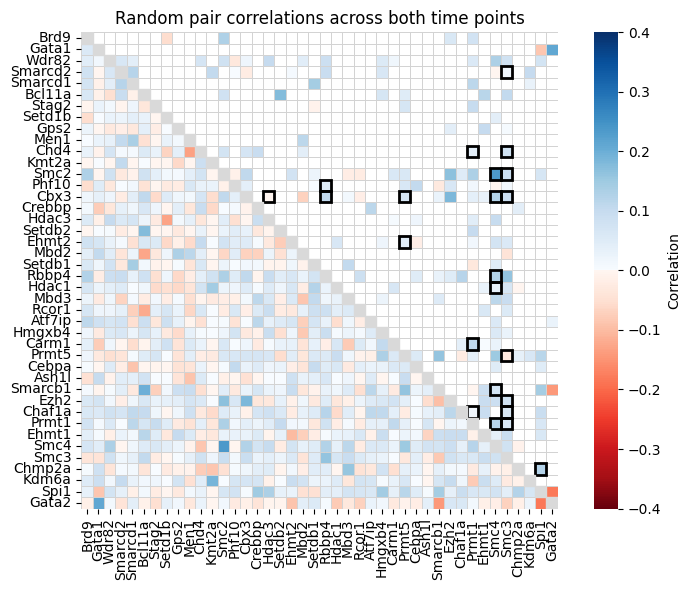

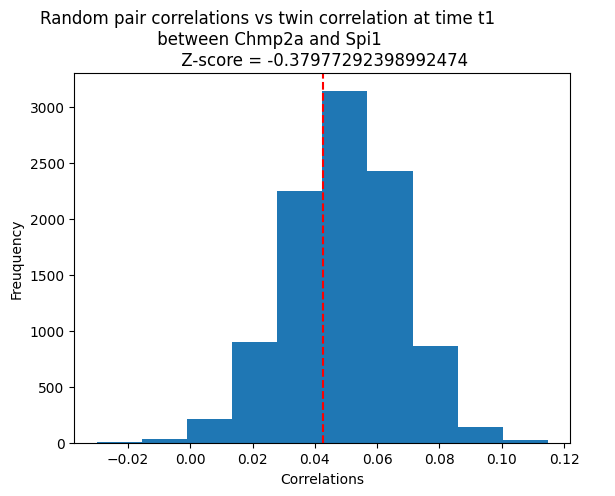

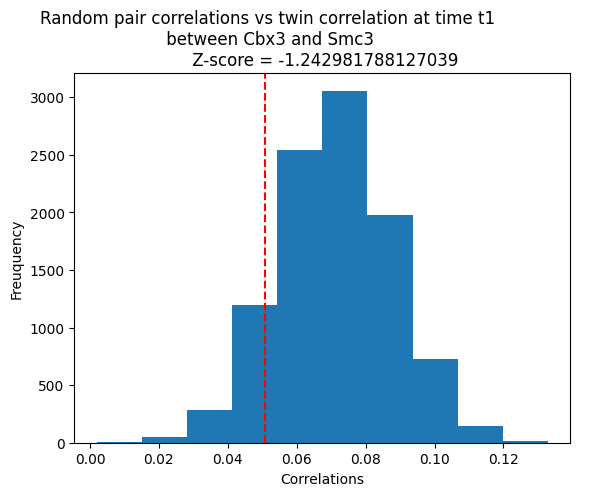

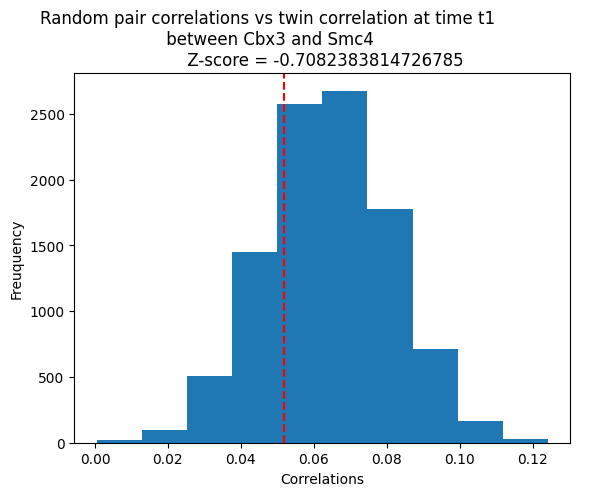

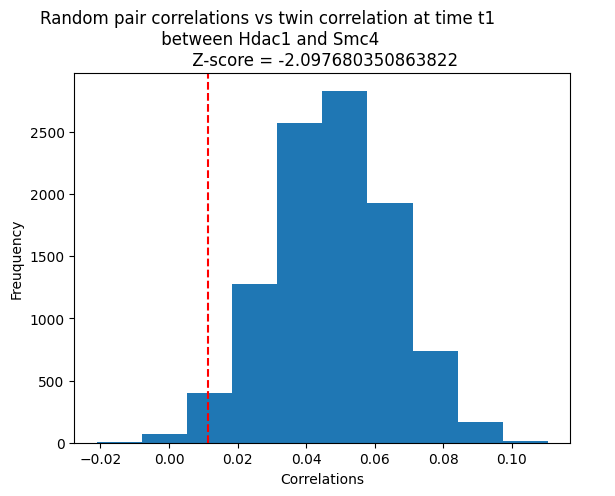

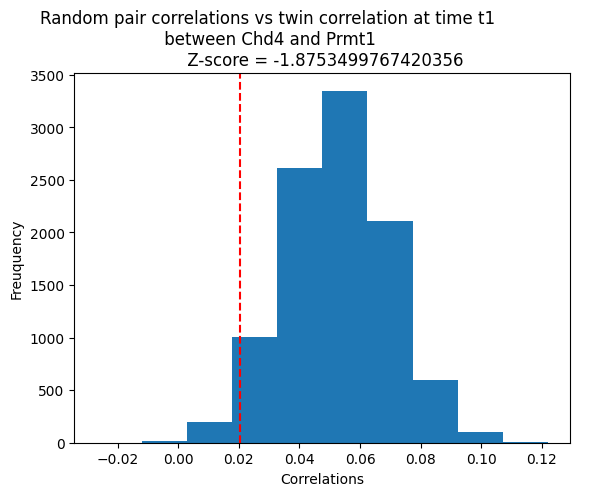

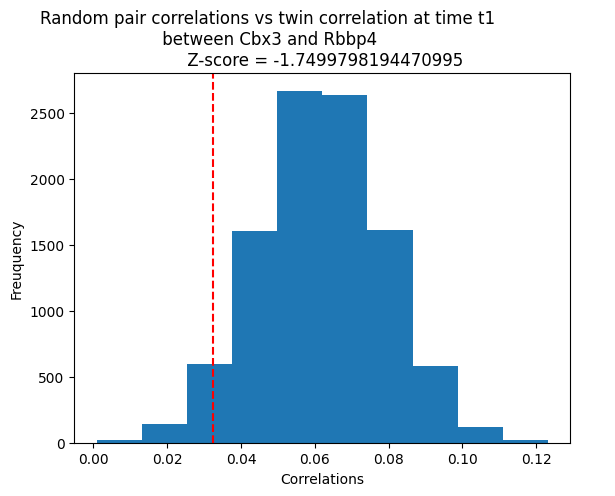

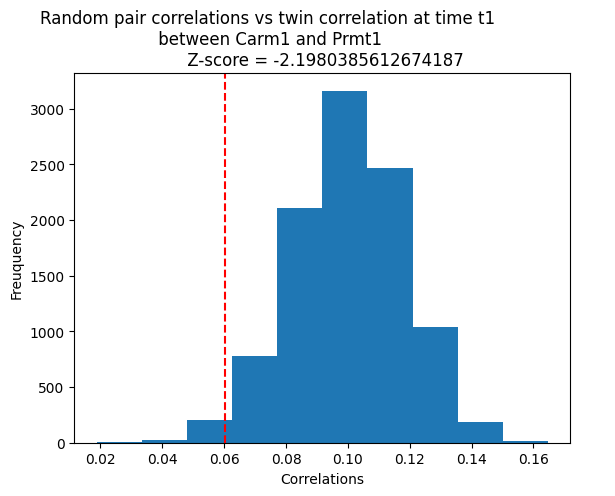

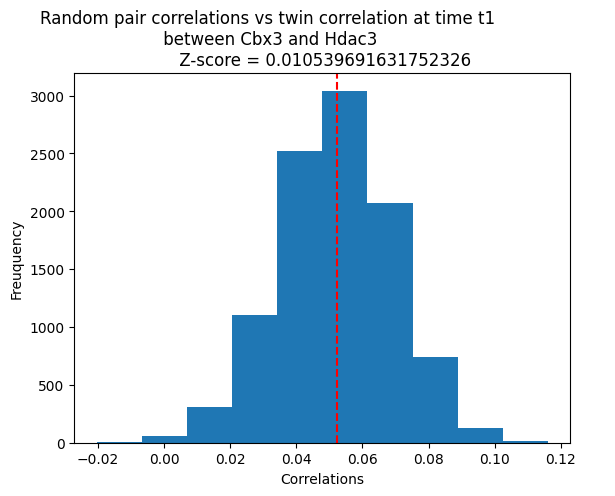

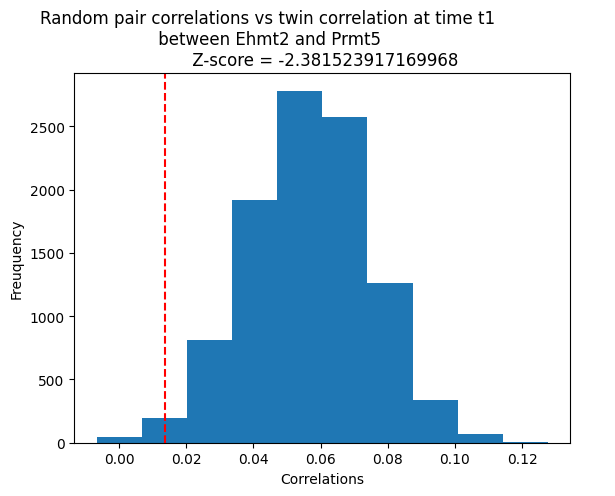

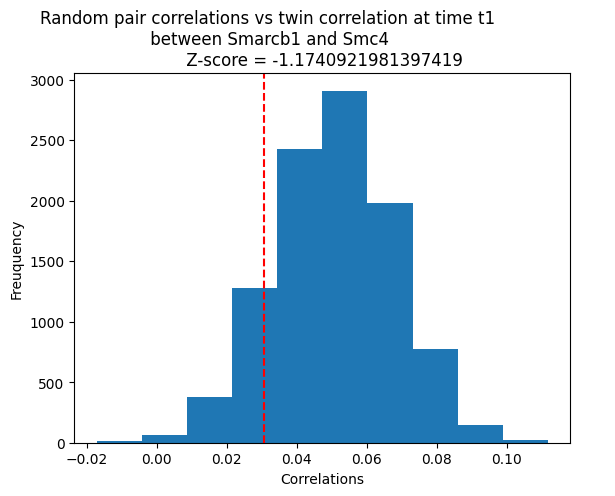

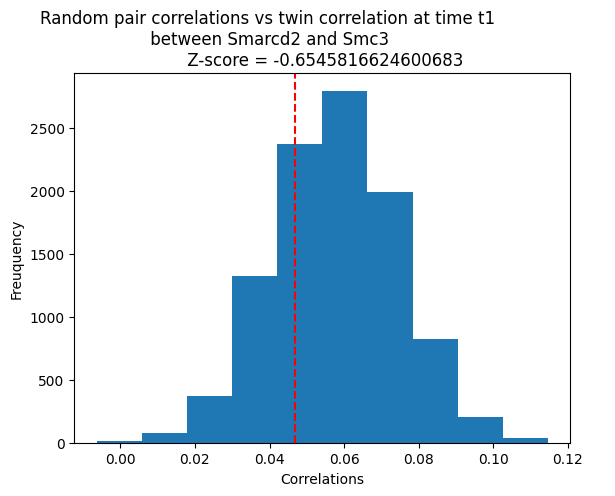

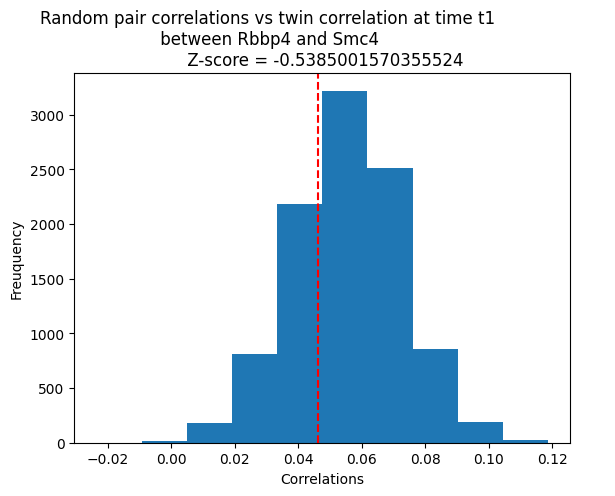

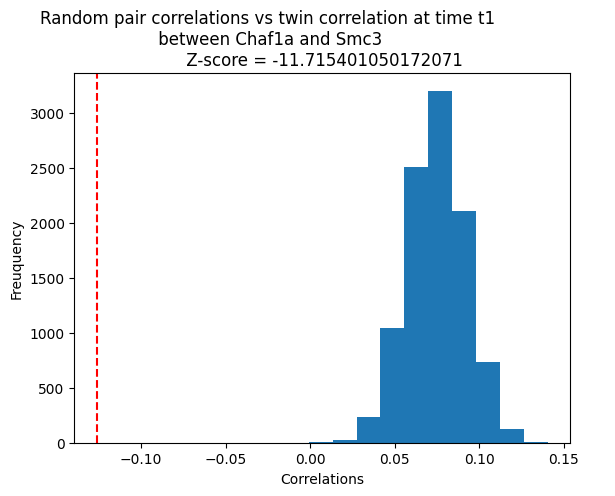

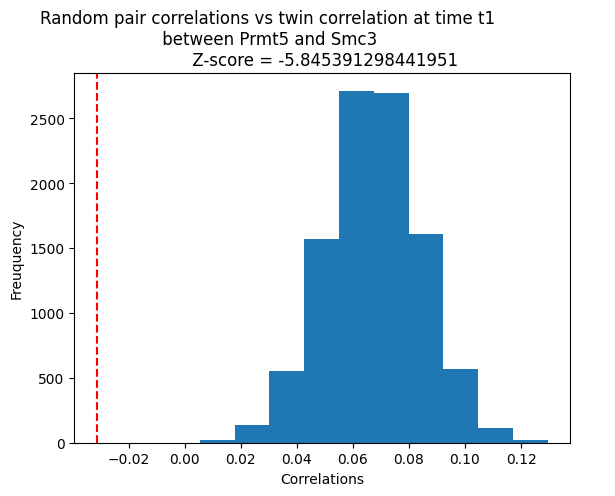

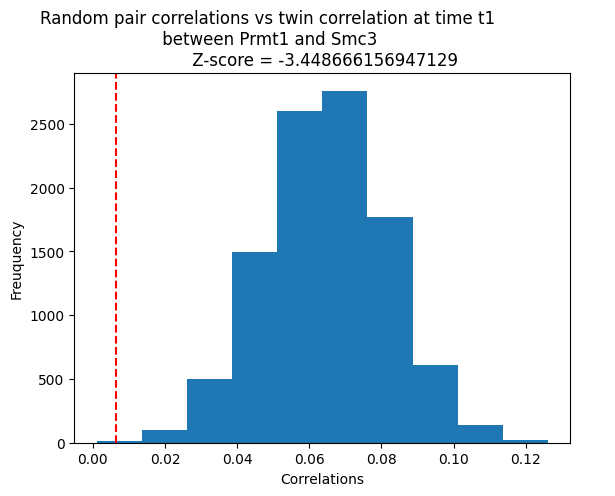

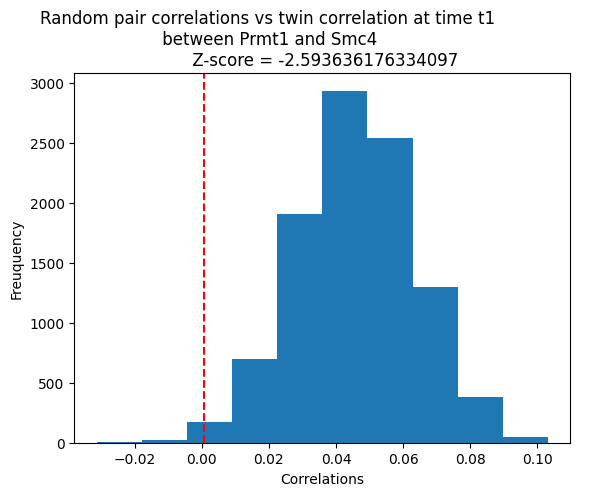

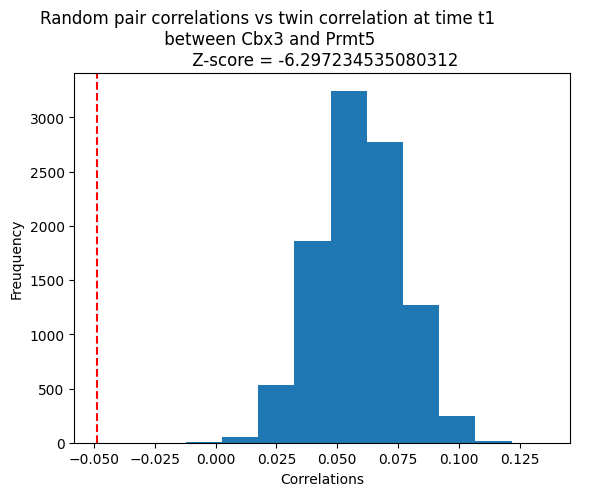

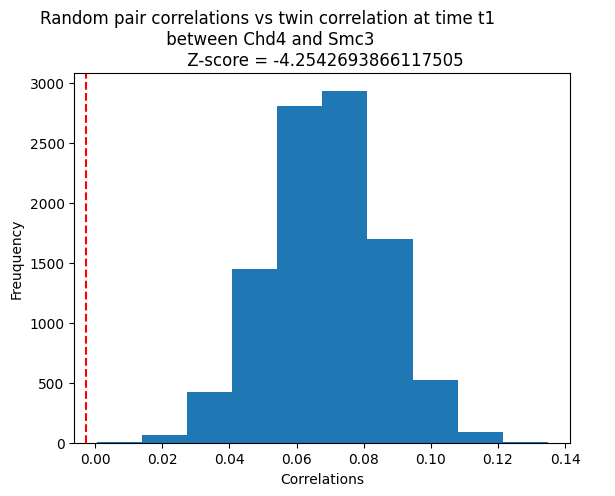

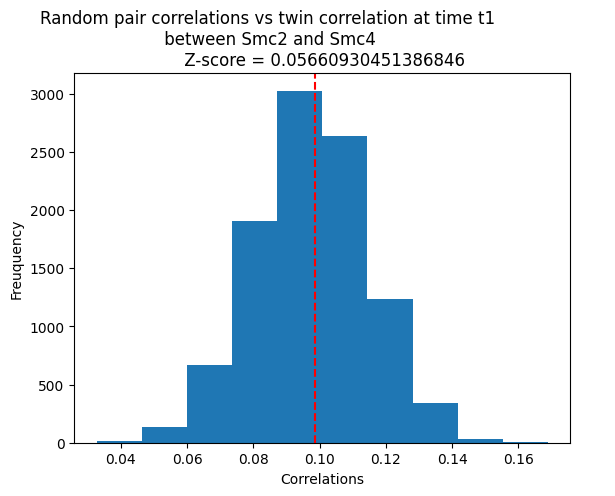

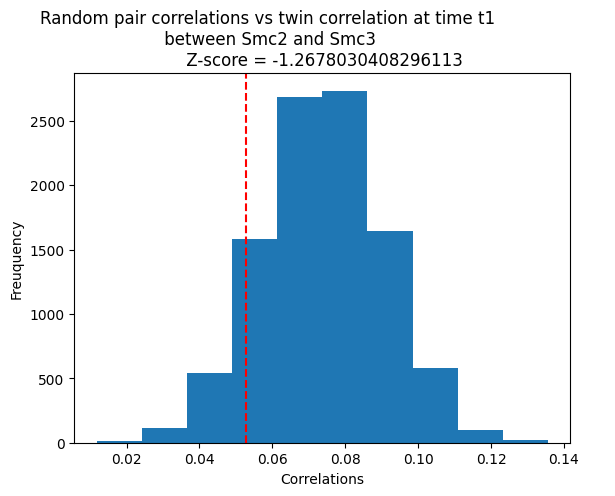

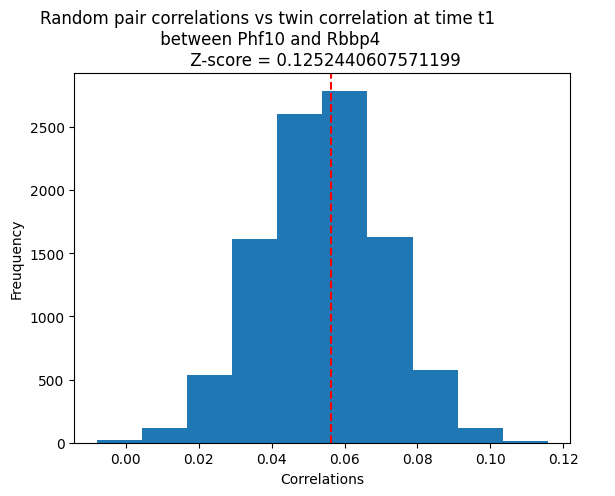

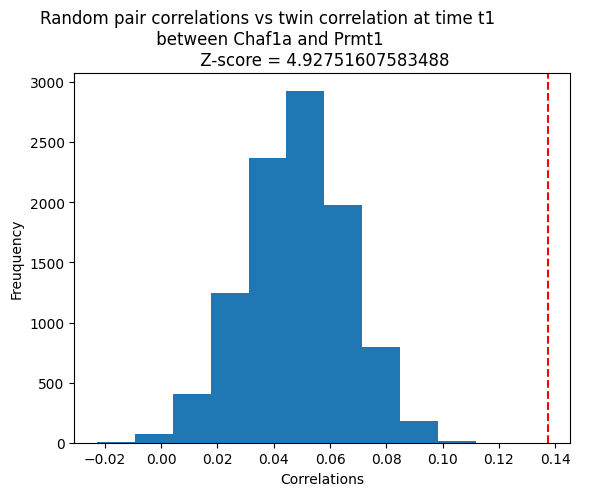

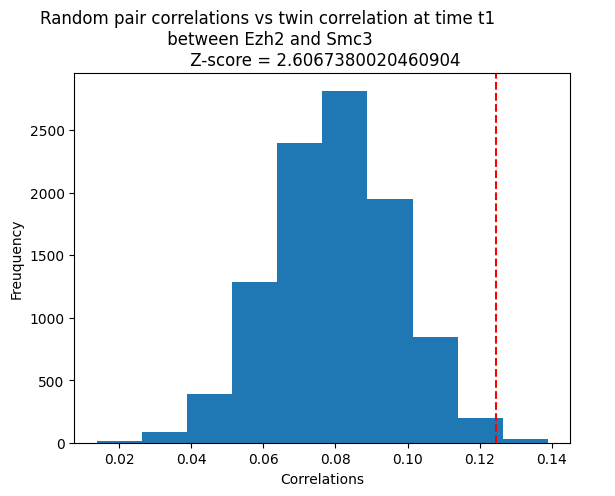

In [42]:
# --- Step 2: Twin/random correlations at t2 ---
twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
    all_t2_measurements, t2_twins, gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t2, gene_list=gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t2}", add_gene_labels=True, add_time=True, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )
    
    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t2, gene_list=gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t2, single_state_regulation_t2 = differentiate_single_state_reg_and_multiple_states(
    all_t1_measurements, consistent_corr, twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2, gene_list, z_score_threshold=z_score_threshold_two_states
)

In [ ]:
# --- Step 2: Twin/random correlations at t2 ---
twin_pair_correlation_matrix_t1_t2, random_pair_correlation_matrix_t1_t2 = calculate_twin_random_pair_correlations(
    all_t1_t2_measurements, t2_twins, gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t1_t2, gene_list=gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t2}", add_gene_labels=True, add_time=True, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )
    
    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t1_t2, gene_list=gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t1_t2, single_state_regulation_t1_t2 = differentiate_single_state_reg_and_multiple_states(
    all_t1_t2_measurements, consistent_corr, twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t1_t2, gene_list, z_score_threshold=z_score_threshold_two_states
)

In [26]:
if len(multiple_states_gene_pairs_t1) > 0:

    multiple_states_no_reg, multiple_states_and_reg = identify_reg_if_multiple_states(
        twin_pair_correlation_matrix_t1,twin_pair_correlation_matrix_t2,random_pair_correlation_matrix_t1,
        random_pair_correlation_matrix_t2,multiple_states_gene_pairs_t1,gene_list
        )
else:
    multiple_states_no_reg, multiple_states_and_reg = [], []

In [27]:
# --- Step 4: Print summary of results ---
all_gene_pairs = list(product(gene_list, repeat=2))
if have_any_output:
    print_summary(no_regulation_t1, single_state_regulation_t1, multiple_states_no_reg, multiple_states_and_reg)


1. No Regulation
  Ehmt1 - Spi1
  Crebbp - Setd1b
  Chmp2a - Ehmt2
  Bcl11a - Setdb1
  Chaf1a - Hmgxb4
  Ehmt1 - Kmt2a
  Cebpa - Gps2
  Ehmt2 - Stag2
  Hdac1 - Mbd2
  Ehmt2 - Setd1b
  Atf7ip - Hmgxb4
  Chaf1a - Rbbp4
  Bcl11a - Smc2
  Setdb2 - Wdr82
  Kmt2a - Wdr82
  Ezh2 - Hdac1
  Chd4 - Chmp2a
  Men1 - Smc3
  Brd9 - Prmt5
  Setd1b - Wdr82
  Men1 - Spi1
  Smarcd1 - Wdr82
  Smarcd2 - Spi1
  Ezh2 - Rcor1
  Bcl11a - Stag2
  Bcl11a - Setd1b
  Ehmt1 - Smarcd2
  Chaf1a - Ehmt2
  Chd4 - Smarcb1
  Mbd2 - Phf10
  Chaf1a - Phf10
  Chmp2a - Setdb1
  Gata2 - Prmt1
  Hmgxb4 - Wdr82
  Brd9 - Spi1
  Kmt2a - Mbd2
  Rbbp4 - Stag2
  Rbbp4 - Setd1b
  Atf7ip - Phf10
  Smc3 - Stag2
  Hdac3 - Hmgxb4
  Ehmt1 - Smc4
  Gata2 - Setdb2
  Kmt2a - Rbbp4
  Carm1 - Smarcb1
  Brd9 - Kmt2a
  Atf7ip - Carm1
  Crebbp - Gata2
  Chd4 - Spi1
  Brd9 - Kdm6a
  Crebbp - Smarcb1
  Gata2 - Smarcd1
  Men1 - Smarcd2
  Mbd3 - Setdb2
  Cbx3 - Gps2
  Chd4 - Kmt2a
  Chmp2a - Stag2
  Chmp2a - Setd1b
  Cebpa - Ezh2
  Ehmt2 - Gata2
  

['Carm1', 'Cbx3', 'Cebpa', 'Chaf1a', 'Chd4', 'Chmp2a', 'Ehmt1', 'Ehmt2', 'Ezh2', 'Hdac3', 'Hmgxb4', 'Mbd3', 'Phf10', 'Prmt1', 'Prmt5', 'Rbbp4', 'Rcor1', 'Smarcb1', 'Smarcd2', 'Smc2', 'Smc3', 'Smc4', 'Spi1', 'Wdr82']
[('Chd4', 'Prmt1'), ('Chaf1a', 'Smc3'), ('Smc3', 'Smc4'), ('Ehmt1', 'Smarcb1'), ('Cbx3', 'Smc2'), ('Chaf1a', 'Prmt1'), ('Cbx3', 'Cbx3'), ('Smc2', 'Smc2'), ('Cebpa', 'Cebpa'), ('Wdr82', 'Wdr82'), ('Smarcd2', 'Smarcd2'), ('Phf10', 'Phf10'), ('Rcor1', 'Rcor1'), ('Hmgxb4', 'Hmgxb4')]


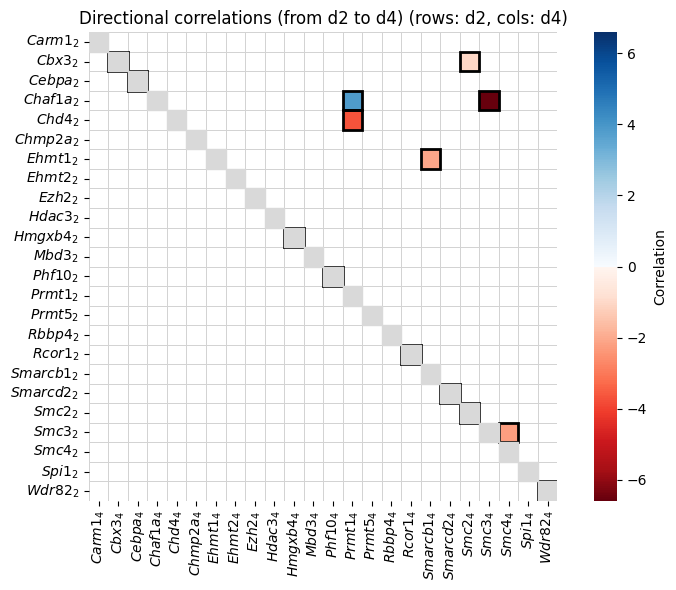

In [23]:
# --- Step 5: Infer directionality of single-state interactions ---
infer_direction_for_which_edges = "single-state"
p_value_threshold_cross_correlation = 0.2

if infer_direction_for_which_edges == "single-state" :
    if len(single_state_regulation_t1) > 0:
        single_state_regulation_list = {g for pair in single_state_regulation_t1 for g in pair}

        # Build self-pairs
        self_pairs = [(g, g) for g in single_state_regulation_list]

        # Append them
        all_gene_pairs = single_state_regulation_t1 + self_pairs
        direction_raw_matrix, direction_scaled_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs)
        
        final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_raw_matrix, gene_pairs=all_gene_pairs, threshold = p_value_threshold_cross_correlation)
    else:
        final_directed_edges = []
        direction_scaled_matrix = pd.DataFrame(
            np.zeros((len(gene_list), len(gene_list))),
            index=gene_list,
            columns=gene_list
        )
else:
    direction_raw_matrix, direction_scaled_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs)
    final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_raw_matrix, gene_pairs=all_gene_pairs, threshold = p_value_threshold_cross_correlation)
print(final_directed_edges)
# print(pre_threshold_direction_matrix)

if plot_correlation_matrices_as_heatmap:
    no_reg_pairs = [pair for pair in all_gene_pairs if pair not in final_directed_edges]
    plot_matrix_as_heatmap(
        corr_matrix=direction_scaled_matrix,
        gene_list=list(direction_scaled_matrix.index),
        no_regulation=no_reg_pairs,                   
        potential_regulation=final_directed_edges,     
        title=f"Directional correlations (from d{t1} to d{t2})",
        add_gene_labels=True,
        add_time=True,
        time=[t1, t2],
        gray_out_no_reg=True,
        black_out_self = True
    )

In [ ]:
### plotting functions ###

from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.patches import Rectangle, FancyArrowPatch

def polygon_layout(gene_list, radius=1.0):
    n = len(gene_list)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    return {
        gene_list[i]: (radius * np.cos(angle), radius * np.sin(angle))
        for i, angle in enumerate(angles)
    }

def make_reds_blues_colormap():
    reds = plt.cm.Reds(np.linspace(1, 0, 128))   # deep red → white
    blues = plt.cm.Blues(np.linspace(0, 1, 128)) # white → deep blue
    colors = np.vstack((reds, blues))
    return LinearSegmentedColormap.from_list('RedsBlues', colors)

def shrink_arrow_endpoints(x1, y1, x2, y2, shrink_source=0.2, shrink_target=0.2, lateral_offset=0.0, scaled_shrink_val = 0.25):
    dx, dy = x2 - x1, y2 - y1
    dist = np.hypot(dx, dy)

    if dist == 0:
        return (x1, y1), (x2, y2)

    scaled_shrink = scaled_shrink_val * dist  # 25% of distance, adjust as needed
    shrink_source = scaled_shrink
    shrink_target = scaled_shrink*0.8

    ux, uy = dx / dist, dy / dist
    orth_x, orth_y = -uy, ux
    x1_off = x1 + shrink_source * ux + lateral_offset * orth_x
    y1_off = y1 + shrink_source * uy + lateral_offset * orth_y
    x2_off = x2 - shrink_target * ux + lateral_offset * orth_x
    y2_off = y2 - shrink_target * uy + lateral_offset * orth_y
    return (x1_off, y1_off), (x2_off, y2_off)

def flat_t_head_arrow(start, end, color='red', linewidth=2, rad=0.2, abs_weight=0.5, ax=None):
    """Draw repression arrow with T-head scaled by abs_weight."""
    arrow = FancyArrowPatch(
        start, end,
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle='-',
        color=color,
        linewidth=linewidth,
        zorder=1
    )
    ax.add_patch(arrow)

    x1, y1 = start
    x2, y2 = end
    dx, dy = x2 - x1, y2 - y1
    dist = np.hypot(dx, dy)
    if dist == 0:
        return

    ux, uy = dx / dist, dy / dist
    tx, ty = x2, y2
    px, py = -uy, ux

    # Scale T-head size with abs_weight (capped)
    t_len = 0.03 + 0.07 * min(abs_weight, 1.0)
    t_xs = [tx - px * t_len, tx + px * t_len]
    t_ys = [ty - py * t_len, ty + py * t_len]
    ax.plot(t_xs, t_ys, color=color, linewidth=linewidth, solid_capstyle='round', zorder=2)


def plot_network(correlation_matrix, gene_list, edges, title=None):
    DG = nx.DiGraph()
    for gene in gene_list:
        DG.add_node(gene)

    # Add all gene-gene interactions (even if directionless)
    # Add all gene-gene interactions (only if both exist in correlation_matrix)
    for g1 in gene_list:
        for g2 in gene_list:
            if g1 == g2:
                continue
            if g1 in correlation_matrix.index and g2 in correlation_matrix.columns:
                if (g1, g2) in edges:
                    val = correlation_matrix.loc[g1, g2]
                    if pd.notna(val):
                        DG.add_edge(g1, g2, weight=val)


    # Define node positions and colors
    pos = polygon_layout(gene_list, radius=max(2, len(gene_list) / 2)) if len(gene_list) > 2 else {
        gene_list[0]: (0, 0),
        gene_list[1]: (1, 0)
    }

    fig, ax = plt.subplots(figsize=(9, 9))
    node_colors = np.array([
    correlation_matrix.loc[g, g] if g in correlation_matrix.index and g in correlation_matrix.columns else 0
    for g in gene_list
    ])

    v = 1
    norm = Normalize(vmin=-v, vmax=v)
    cmap = make_reds_blues_colormap()
    node_rgba = cmap(norm(node_colors))
    node_rgba[:, -1] = 0.8

    nx.draw_networkx_nodes(DG, pos, ax=ax, node_color=node_rgba, node_size=6000, edgecolors='black', linewidths=1.5)

    print(DG.nodes)
    # labels = {node: f"$g{int(node.split('_')[-1])}$" for node in DG.nodes()}
    labels = {node: node for node in DG.nodes()}
    nx.draw_networkx_labels(DG, pos, labels=labels, font_size=16, ax=ax)

    # Draw edges
    for u, v in DG.edges():
        raw_weight = correlation_matrix.loc[u, v]
        if pd.isnull(raw_weight) or raw_weight == 0:
            continue

        x1, y1 = pos[u]
        x2, y2 = pos[v]
        offset = -0.15 if DG.has_edge(v, u) else 0.0
        rad = 0.2 if DG.has_edge(v, u) else 0.0
        start, end = shrink_arrow_endpoints(x1, y1, x2, y2, lateral_offset=offset)
        color = cmap(norm(raw_weight))
        abs_weight = abs(raw_weight)

        if raw_weight > 0:
            head_length = min(10 + abs_weight * 10, 20)
            head_width = min(10 + abs_weight * 10, 20)
            arrow_style = f'->,head_length={head_length},head_width={head_width}'

            # Positive correlation → activation (arrow)
            arrow = FancyArrowPatch(
                start, end,
                connectionstyle=f'arc3,rad={rad}',
                arrowstyle=arrow_style,
                mutation_scale=1,
                color=color,
                linewidth=min(abs_weight * 10, 5.0),
                zorder=1
            )
            ax.add_patch(arrow)
        elif raw_weight < 0:
            # Negative correlation → repression (flat T-bar)
            flat_t_head_arrow(
                start, end,
                color=color,
                linewidth=min(abs_weight * 10, 5.0),
                rad=rad,
                abs_weight=abs_weight,
                ax=ax
            )


    ax.set_title(title or "Inferred GRN", fontsize=16, fontweight='bold')
    ax.axis('off')

    if len(pos) > 0:
        x_vals, y_vals = zip(*pos.values())
        x_range = max(x_vals) - min(x_vals)
        y_range = max(y_vals) - min(y_vals)
        ax.set_xlim(min(x_vals) - 0.3 * x_range, max(x_vals) + 0.3 * x_range)
        ax.set_ylim(min(y_vals) - 0.3 * y_range, max(y_vals) + 0.3 * y_range)

    if len(gene_list) == 2:
        ax.set_xlim(-0.5, len(gene_list) - 0.5)
        ax.set_ylim(-0.5, 0.5)
        ax.set_aspect('equal')
        plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1)
    else:
        plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.05)

    plt.tight_layout()
    plt.show()

In [84]:
# --- Step 6: Visualize the inferred network ---
if (len(single_state_regulation) >= 0):
    if have_any_output:
        if (len(final_directed_edges) > 0):
            plot_network(direction_scaled_matrix, gene_list, final_directed_edges)
        else:
            plot_network(direction_scaled_matrix, gene_list, final_directed_edges)

try:
    correlation_matrices = {
        "direction_matrix": direction_scaled_matrix, 
        "direction_raw_matrix": direction_raw_matrix, 
        "pairwise_gene_gene_correlation_matrix": pairwise_gene_gene_correlation_matrix,
        "twin_pair_correlation_matrix_t2": twin_pair_correlation_matrix_t2,
        "random_pair_correlation_matrix_t2": random_pair_correlation_matrix_t2,
        "twin_pair_correlation_matrix_t1": twin_pair_correlation_matrix_t1,
        "random_pair_correlation_matrix_t1": random_pair_correlation_matrix_t1
    }
except:
    correlation_matrices = {
        "direction_matrix": None, 
        "direction_raw_matrix": None, 
        "pairwise_gene_gene_correlation_matrix": pairwise_gene_gene_correlation_matrix,
        "random_pair_correlation_matrix": random_pair_correlation_matrix_t2,
        "twin_pair_correlation_matrix_t2": twin_pair_correlation_matrix_t2,
        "twin_pair_correlation_matrix_t1": twin_pair_correlation_matrix_t1,
    }